## Workflow
Clean data → handle outliers → select audio features → scale → PCA → determine number of clusters → K-Means → evaluate and interpret clusters.

# **Import necessary libraries**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load the Data**

In [32]:
df = pd.read_csv("ML_spotify_data.csv")

In [33]:
df.head()

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,Sixty Years On - Piano Demo,['Elton John'],25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,Got to Find Another Way,['The Guess Who'],21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,Feelin' Alright - Live At The Fillmore East/1970,['Joe Cocker'],22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,Caravan - Take 7,['Van Morrison'],23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


# **Data Cleaning and Preprocessing**

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          10000 non-null  str    
 1   artists       10000 non-null  str    
 2   popularity    10000 non-null  int64  
 3   danceability  10000 non-null  float64
 4   valence       10000 non-null  float64
 5   energy        10000 non-null  float64
 6   explicit      10000 non-null  int64  
 7   key           10000 non-null  int64  
 8   liveness      10000 non-null  float64
 9   loudness      10000 non-null  float64
 10  speechiness   10000 non-null  float64
 11  tempo         10000 non-null  float64
dtypes: float64(7), int64(3), str(2)
memory usage: 937.6 KB


In [35]:
df.isnull().sum()

name            0
artists         0
popularity      0
danceability    0
valence         0
energy          0
explicit        0
key             0
liveness        0
loudness        0
speechiness     0
tempo           0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(1)

In [37]:
# view duplicated row
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
636,Raped and Freezin',['Alice Cooper'],25,0.6,0.725,0.761,0,2,0.887,-8.819,0.0337,123.595
658,Raped and Freezin',['Alice Cooper'],25,0.6,0.725,0.761,0,2,0.887,-8.819,0.0337,123.595


In [38]:
# drop the duplicated row
df.drop_duplicates(inplace=True)

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,9999.0,37.558056,12.559743,0.0,27.0000,36.0000,46.0000,86.000
danceability,9999.0,0.549502,0.178105,0.0,0.4300,0.5570,0.6810,0.986
valence,9999.0,0.523128,0.261461,0.0,0.3130,0.5240,0.7420,0.996
energy,9999.0,0.592592,0.251815,0.0,0.4140,0.6160,0.8010,1.000
explicit,9999.0,0.103210,0.304249,0.0,0.0000,0.0000,0.0000,1.000
key,9999.0,5.205921,3.562083,0.0,2.0000,5.0000,9.0000,11.000
liveness,9999.0,0.209719,0.193584,0.0,0.0939,0.1290,0.2610,1.000
loudness,9999.0,-9.822424,5.321321,-60.0,-12.3485,-8.7610,-6.0705,1.073
speechiness,9999.0,0.081431,0.100476,0.0,0.0342,0.0451,0.0774,0.957
tempo,9999.0,120.179381,30.262242,0.0,96.1905,118.3280,139.6120,224.437


In [48]:
# select the numerical columns from dataset
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['popularity', 'danceability', 'valence', 'energy', 'explicit', 'key',
       'liveness', 'loudness', 'speechiness', 'tempo'],
      dtype='str')


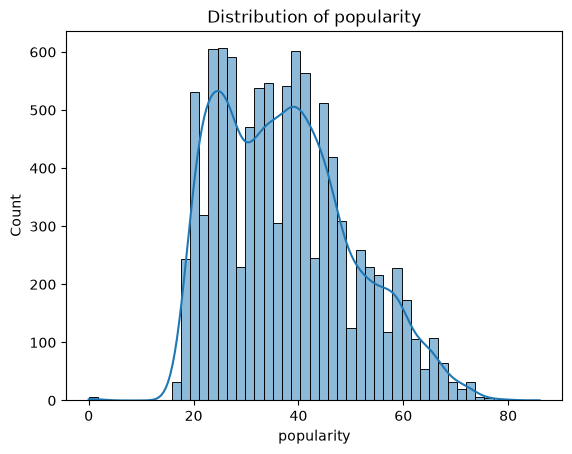

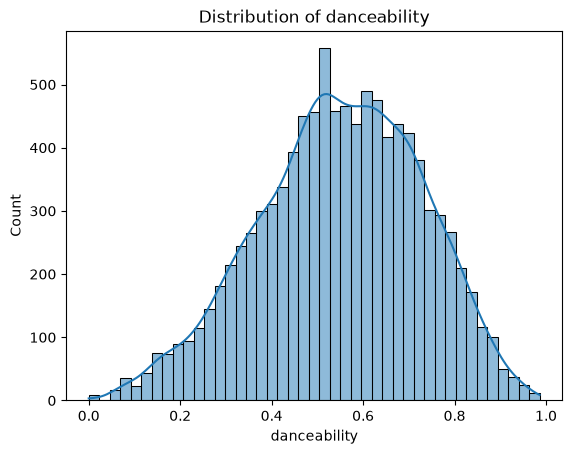

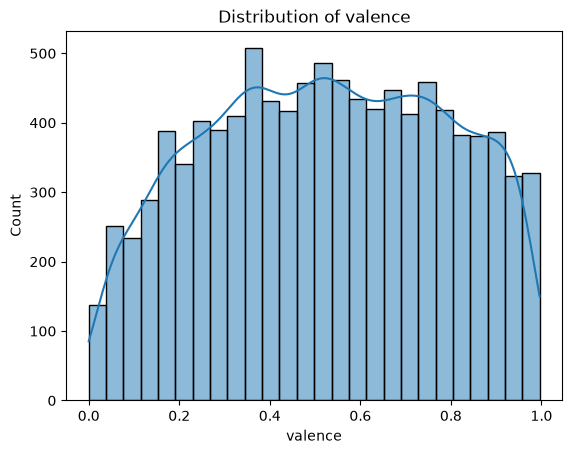

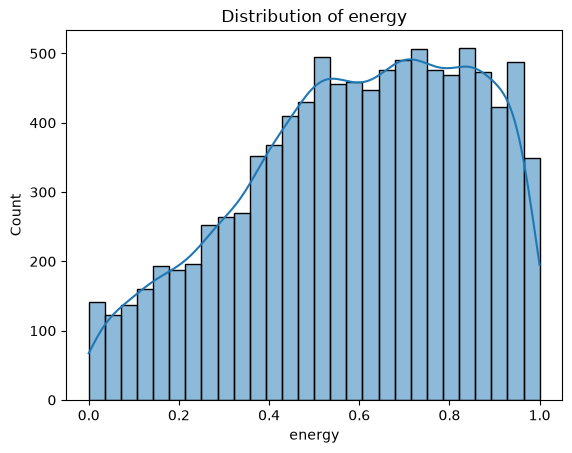

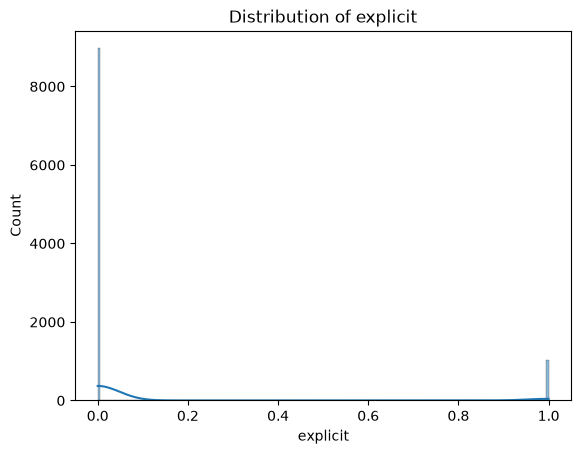

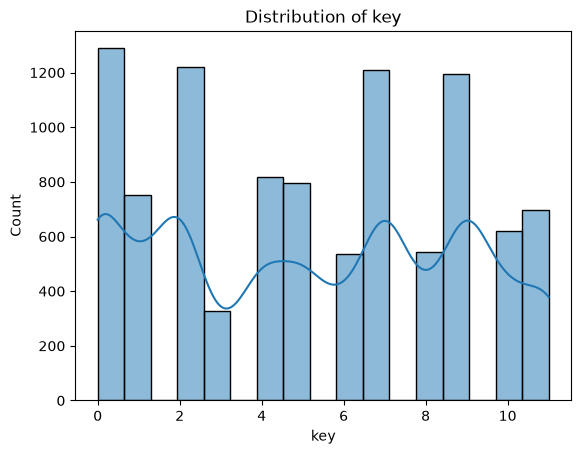

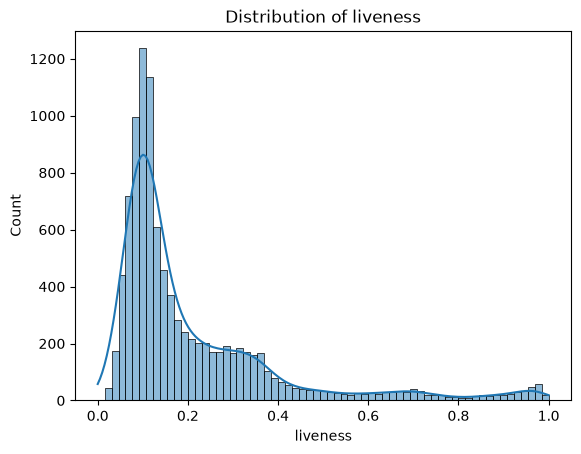

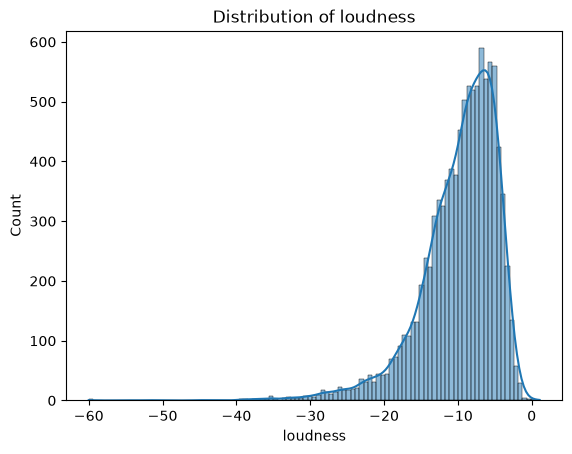

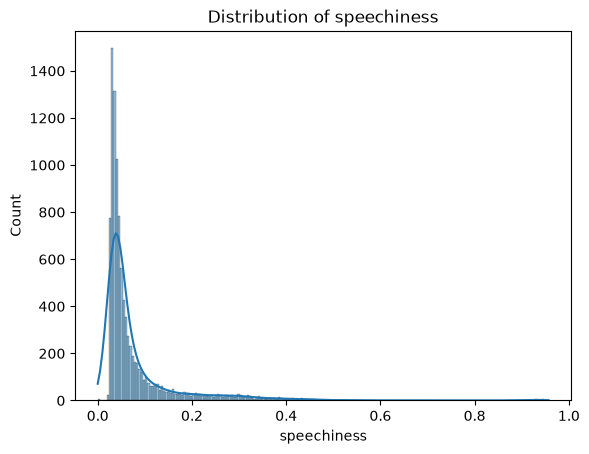

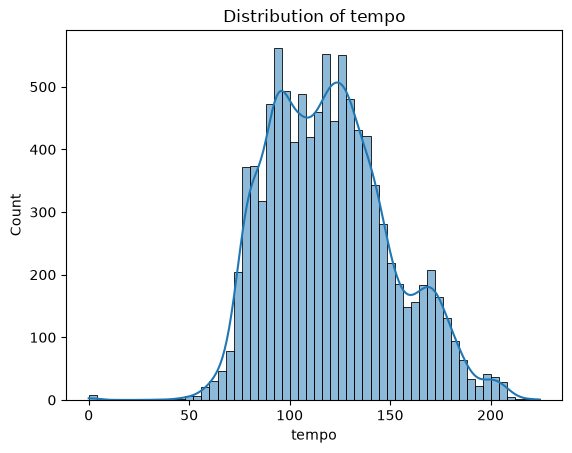

In [42]:
# check for distribution of numerical columns
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

They are mostly skewed apart from valence and key.

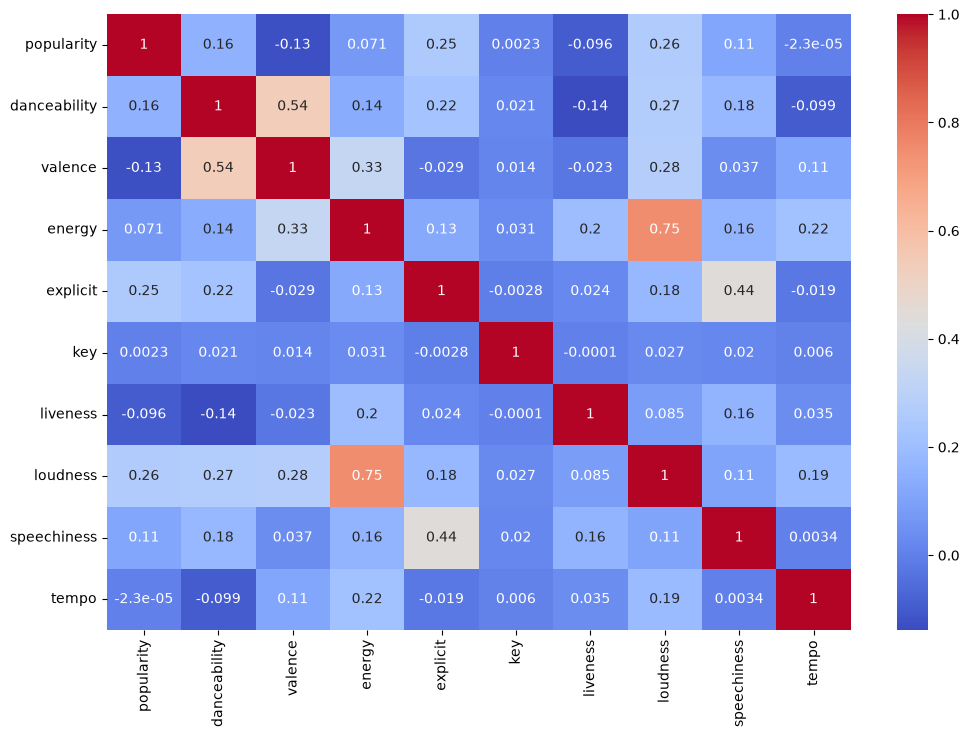

In [43]:
# corelation analysis
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Outlier detection

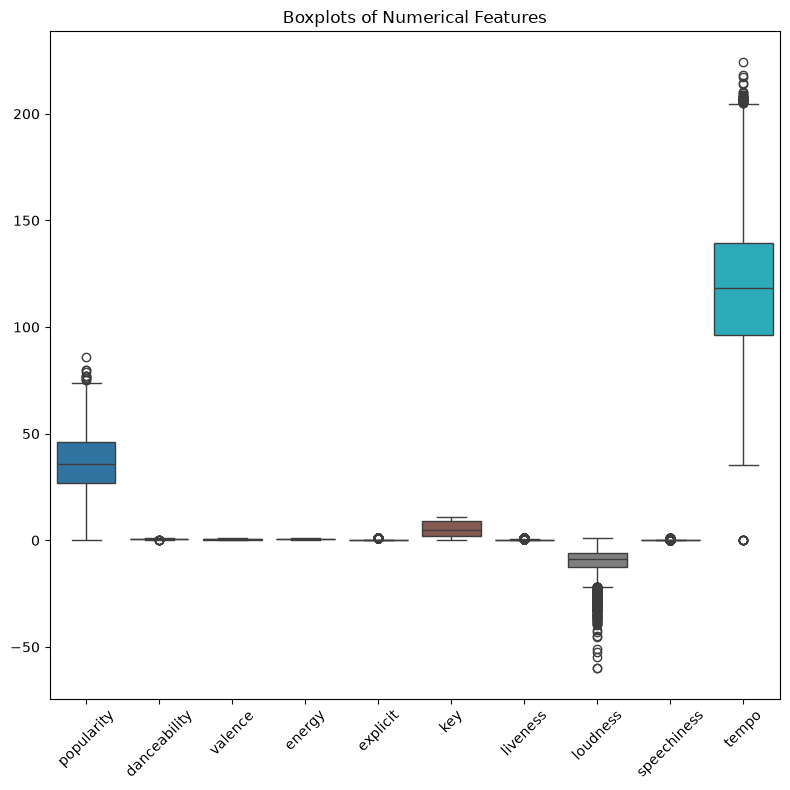

In [44]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=df[numerical_cols])

plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features')
plt.tight_layout()
plt.show()

In [55]:
Q1 = df['loudness'].quantile(0.25)
Q3 = df['loudness'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['loudness'] < lower) |
    (df['loudness'] > upper)
]

print(outliers)

                                                   name  \
41                                     Dayton Ohio 1903   
58    Orfeo ed Euridice Wq. 30 - Vienna Version (176...   
94    Les Contes d'Hoffmann / Act 4: Entr'acte (Barc...   
202                          I Need Somebody to Lean On   
310                   Remarks by Reverend C L. Franklin   
...                                                 ...   
9870    Kitzbuhel Mild Rain And Thunder 2 Redux - Redux   
9883                                         Sea Change   
9938                                           Nepenthe   
9992                  We Contain Multitudes (from home)   
9994                                    Med slutna ögon   

                                                artists  popularity  \
41                                    ['Harry Nilsson']          20   
58    ['Christoph Willibald Gluck', 'Orchestra of th...          26   
94    ['Jacques Offenbach', 'Orchestra of the Royal ...          26   
202    

In [53]:
print(outliers['loudness'].sort_values())

6335   -60.000
5597   -60.000
9218   -54.837
9315   -52.220
9367   -51.123
         ...  
4930   -21.814
5307   -21.787
2214   -21.783
3009   -21.781
447    -21.778
Name: loudness, Length: 343, dtype: float64


In [56]:
Q1 = df['popularity'].quantile(0.25)
Q3 = df['popularity'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['popularity'] < lower) |
    (df['popularity'] > upper)
]

print(outliers)

                                                   name  \
9744              Own It (feat. Ed Sheeran & Burna Boy)   
9822                                             Morado   
9823                                 Only You Freestyle   
9833                                       Se Me Olvidó   
9836                  Don't Say Goodbye (feat. Tove Lo)   
9849                                        Amor Tóxico   
9907                                             Tattoo   
9921           Ayer Me Llamó Mi Ex (feat. Lenny Santos)   
9971                                           Caramelo   
9979  Elegí (feat. Farruko, Anuel AA, Sech, Dímelo F...   
9997                                                AYA   

                                                artists  popularity  \
9744             ['Stormzy', 'Burna Boy', 'Ed Sheeran']          76   
9822                                       ['J Balvin']          77   
9823                            ['Headie One', 'Drake']          75   
9833   

In [57]:
Q1 = df['tempo'].quantile(0.25)
Q3 = df['tempo'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['tempo'] < lower) |
    (df['tempo'] > upper)
]

print(outliers)

                                                   name  \
88                                  Check Out Your Mind   
422                                  Song of the Viking   
442                                      Chapel of Love   
508            Yonder Stands the Sinner - 2016 Remaster   
792   Down To Seeds And Stems Again Blues - Live (19...   
1406                              Electro Lux Imbroglio   
1507                                     Constantinople   
1547        Sand in My Joints - 2006 Remastered Version   
1727          Christmas Time's a-Comin' - 2004 Remaster   
2393                                              光陰的故事   
2601                                            Someday   
2717                            Like Calling up Thunder   
2889                                           Hold You   
3101                                  Manhattan Skyline   
3210                              Calm Inside the Storm   
3573                Surrender - 2005 Remastered Version 

In [58]:
for col in ['loudness', 'popularity', 'tempo']:
    print(f"\n{col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


loudness
Min: -60.0
Max: 1.073

popularity
Min: 0
Max: 86

tempo
Min: 0.0
Max: 224.437


### Inisghts
- Kept outliers especially since majority are in popularity (a song having very low or very high popularity), tempo (very slow or very fast tempos) and loudness (very quiet or very loud songs) which are not necessarily errors but legitimate observations.

# **Feature Engineering**

In [62]:
# selecting relevant clustering features
features = [
    'danceability',
    'valence',
    'energy',
    'liveness',
    'loudness',
    'speechiness',
    'tempo',
    'key'
]

X = df[features]

# **Scaling**

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Dimensionality Reduction**

Used PCA to reduce the feature space  and visualize the clusters.

In [64]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained:", pca.explained_variance_ratio_.sum())

Variance explained: 0.45470827994186325


# **Modelling**

### 1. K-Means Clustering

In [65]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

print(kmeans_labels)

[2 0 2 ... 2 1 2]


In [67]:
print(pd.Series(kmeans_labels).value_counts())

2    4575
1    3014
0    2410
Name: count, dtype: int64


In [ ]:
# add K-Means cluster labels to the dataframe
df['KMeans'] = kmeans_labels

In [72]:
df.groupby('KMeans')[features].mean()

,danceability,valence,energy,liveness,loudness,speechiness,tempo,key
KMeans,,,,,,,,
0,0.425452,0.280550,0.272546,0.157218,-15.593243,0.044704,107.953601,4.990041
1,0.447597,0.455616,0.777767,0.337769,-7.085173,0.098152,137.818113,5.345388
2,0.681984,0.695389,0.639191,0.153016,-8.585791,0.089762,114.999270,5.227760


- Cluster 0 — lower-energy, less danceable songs. Could represent quieter, calmer or more subdued songs.
- Cluster 1 — high-energy songs. Could represent energetic, louder and faster songs.
- Cluster 2 — highly danceable/positive songs. Could represent upbeat, happy and dance-oriented songs.

### 2. Hierarchical Clustering

- Used agglomerative because it does not require randomly choosing initial cluster centers and it can capture hierarchical relationships between songs.

In [66]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

print(hierarchical_labels)

[0 0 0 ... 0 2 0]


In [ ]:
# add hierarchical clustering labels to the dataframe
df['Hierarchical'] = hierarchical_labels

In [74]:
df['Hierarchical'].value_counts()

Hierarchical
0    6981
1    2013
2    1005
Name: count, dtype: int64

In [75]:
# check characteristics of each cluster
df.groupby('Hierarchical')[features].mean()

,danceability,valence,energy,liveness,loudness,speechiness,tempo,key
Hierarchical,,,,,,,,
0,0.566089,0.586082,0.678130,0.224702,-8.301159,0.059133,124.823735,5.277324
1,0.416621,0.269735,0.263601,0.140697,-16.042647,0.042070,105.064284,4.889717
2,0.700449,0.593375,0.657385,0.243893,-7.930525,0.315156,118.193766,5.343284


- Cluster 0 — high-energy songs. Could represent energetic, louder and faster songs.
- Cluster 1 — lower-energy, less danceable songs. Could represent quieter, calmer or more subdued songs.
- Cluster 2 — highly danceable/positive songs. Could represent upbeat, happy and dance-oriented songs.

### 3. DBSCAN

In [77]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

print(dbscan_labels)

[-1 -1 -1 ... -1 -1 -1]


In [78]:
# add labesl to df
df['DBSCAN'] = dbscan_labels

In [79]:
# check number of songs in each cluster
df['DBSCAN'].value_counts()

DBSCAN
-1     9903
 2       13
 1       10
 5        6
 7        6
 15       6
 9        5
 0        5
 3        5
 6        5
 8        5
 4        5
 10       5
 14       5
 11       5
 12       5
 13       5
Name: count, dtype: int64

- 9,903 songs → noise (-1)
- The remaining 96 songs = 16 small clusters and most clusters contain only 5–13 songs.
- Most songs are not sufficiently similar to enough neighboring songs to form dense clusters under the current parameters (eps=0.5, min_samples=5).

In [ ]:
# test and tuning several eps values
for eps in [0.5, 0.7, 0.9, 1.0, 1.2, 1.5]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"eps={eps}: clusters={n_clusters}, noise={n_noise}")

eps=0.5: clusters=16, noise=9903
eps=0.7: clusters=60, noise=6141
eps=0.9: clusters=17, noise=2798
eps=1.0: clusters=29, noise=1764
eps=1.2: clusters=5, noise=659
eps=1.5: clusters=1, noise=233


use eps=1.2 since it only leaves 659 songs and has 5 clusters

In [82]:
dbscan = DBSCAN(eps=1.2, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN'] = dbscan_labels

In [83]:
df['DBSCAN'].value_counts()

DBSCAN
 0    9323
-1     659
 3       5
 1       4
 2       4
 4       4
Name: count, dtype: int64

- 9,323 out of 9,999 songs are in one large cluster.
- DBSCAN is therefore saying that most of your songs are sufficiently similar to form one dense group. 659 songs don't fit into that dense region, so they're classified as noise. The other clusters are extremely small (only 4–5 songs each), so they aren't particularly useful for interpreting broad music patterns

In [84]:
# examine the cluster characteristics
df.groupby('DBSCAN')[features].mean()

,danceability,valence,energy,liveness,loudness,speechiness,tempo,key
DBSCAN,,,,,,,,
-1,0.512724,0.444876,0.575361,0.468235,-12.085703,0.259252,124.636690,5.160850
0,0.552236,0.528588,0.593513,0.190927,-9.665497,0.068597,119.779078,5.209589
1,0.416250,0.895500,0.884750,0.838750,-6.911250,0.049225,171.542000,6.500000
2,0.142950,0.264500,0.967000,0.960250,-7.347000,0.092875,193.799500,1.250000
3,0.807800,0.618600,0.473000,0.101040,-10.081600,0.433200,139.748800,6.600000
4,0.453750,0.455250,0.767750,0.174625,-7.767750,0.279250,169.399750,5.000000


### 4. Gaussian Mixture Model

GMM is similar to K-Means in that you specify the number of clusters, but instead of simply assigning each song to the nearest centroid, GMM models the data as a mixture of probability distributions.

In [86]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

print(gmm_labels)

[0 0 1 ... 1 2 1]


In [87]:
df['GMM'] = gmm_labels

In [88]:
df['GMM'].value_counts()

GMM
0    4028
1    3752
2    2219
Name: count, dtype: int64

In [89]:
df.groupby('GMM')[features].mean()

,danceability,valence,energy,liveness,loudness,speechiness,tempo,key
GMM,,,,,,,,
0,0.523115,0.472548,0.464639,0.104513,-11.925592,0.036542,115.780179,5.129345
1,0.554121,0.571262,0.671436,0.214770,-8.454451,0.057696,123.334399,5.260661
2,0.589590,0.533555,0.691543,0.392152,-8.317726,0.203047,122.830287,5.252366


- Cluster 0 — moderate and lower-energy songs
- Cluster 1 — energetic and positive songs
- Cluster 2 — energetic, live and speech-heavy songs

# **Model Evaluation**

### K-Means - Elbow Method

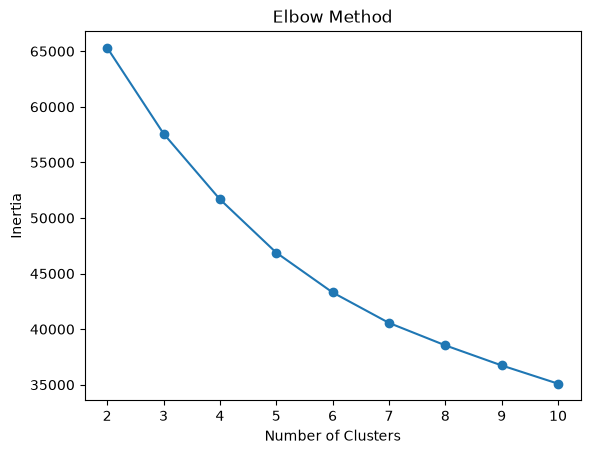

In [90]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

### K-Means - Silhouette Score

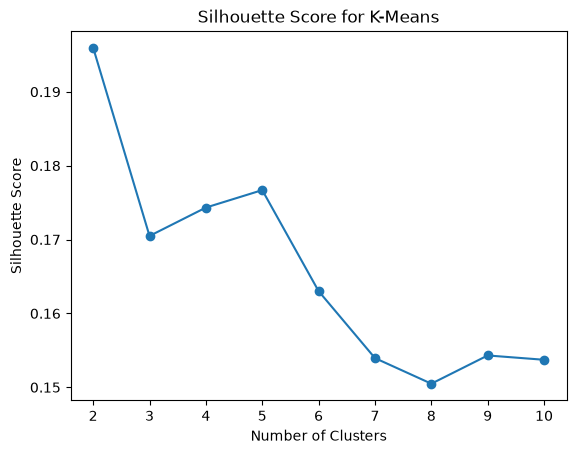

In [91]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-Means')
plt.show()

### Hierarchical - Dendrogram

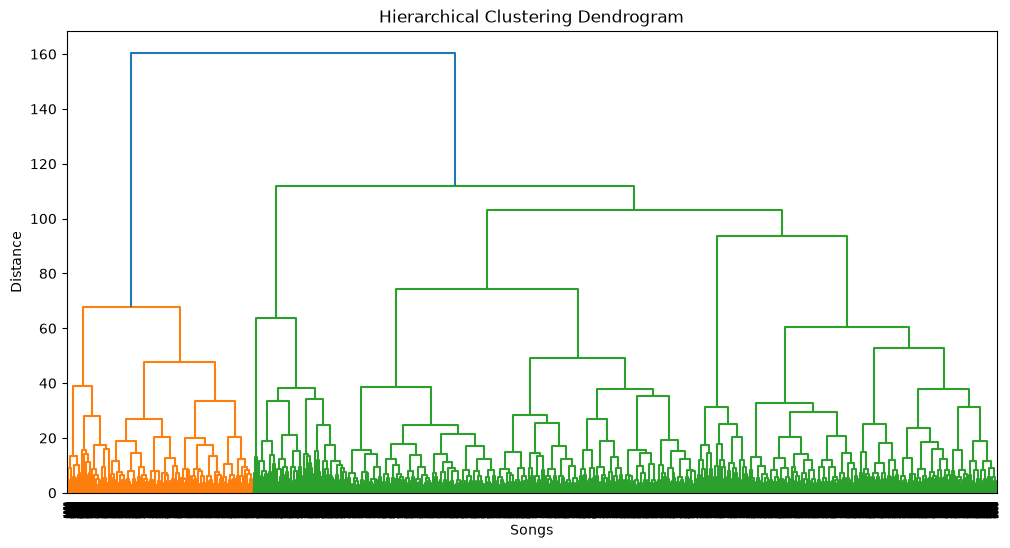

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Songs')
plt.ylabel('Distance')
plt.show()

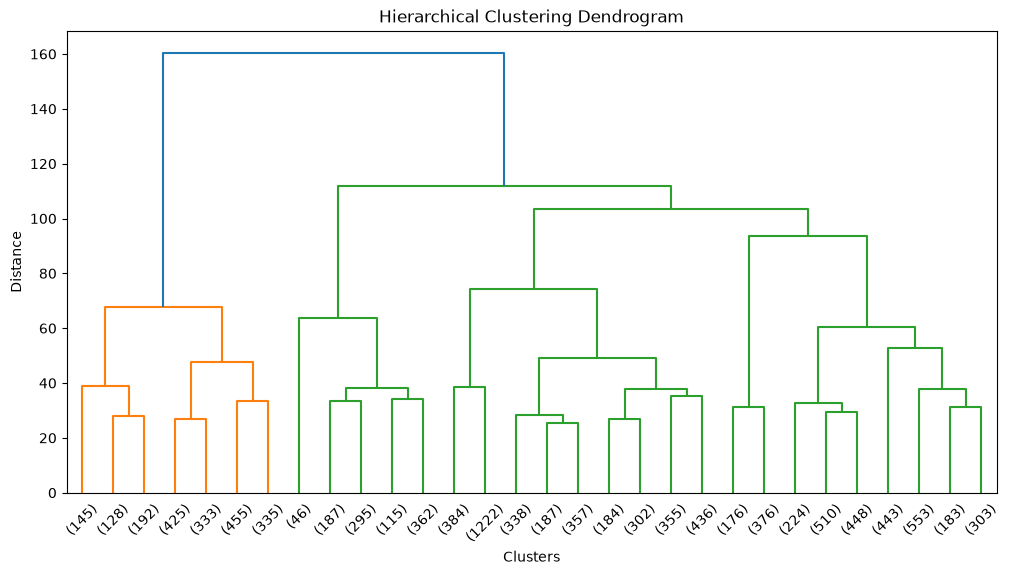

In [93]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30 # display only the last 30 merged groups
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Clusters')
plt.ylabel('Distance')
plt.show()

### Cluster distribution and interpretability

In [94]:
print("K-Means:")
print(df['KMeans'].value_counts())

print("\nHierarchical:")
print(df['Hierarchical'].value_counts())

print("\nDBSCAN:")
print(df['DBSCAN'].value_counts())

print("\nGMM:")
print(df['GMM'].value_counts())

K-Means:
KMeans
2    4575
1    3014
0    2410
Name: count, dtype: int64

Hierarchical:
Hierarchical
0    6981
1    2013
2    1005
Name: count, dtype: int64

DBSCAN:
DBSCAN
 0    9323
-1     659
 3       5
 1       4
 2       4
 4       4
Name: count, dtype: int64

GMM:
GMM
0    4028
1    3752
2    2219
Name: count, dtype: int64


In [95]:
df.groupby('KMeans')[features].mean()

,danceability,valence,energy,liveness,loudness,speechiness,tempo,key
KMeans,,,,,,,,
0,0.425452,0.280550,0.272546,0.157218,-15.593243,0.044704,107.953601,4.990041
1,0.447597,0.455616,0.777767,0.337769,-7.085173,0.098152,137.818113,5.345388
2,0.681984,0.695389,0.639191,0.153016,-8.585791,0.089762,114.999270,5.227760


### PCA visualization

In [96]:
# reduce scale to two dimensions and visualize the clusters.
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

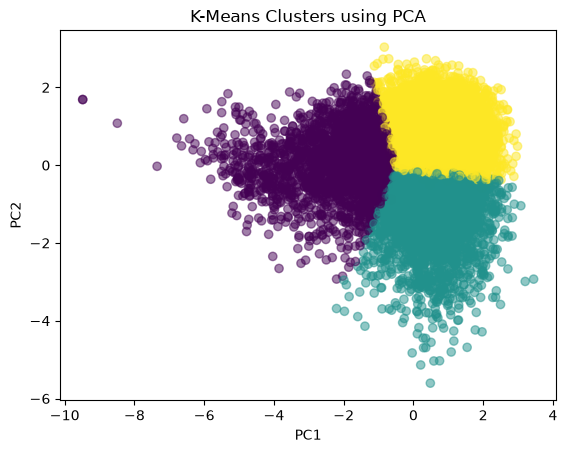

In [97]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['KMeans'],
    alpha=0.5
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters using PCA')
plt.show()

# t-SNE Visualizations

In [98]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

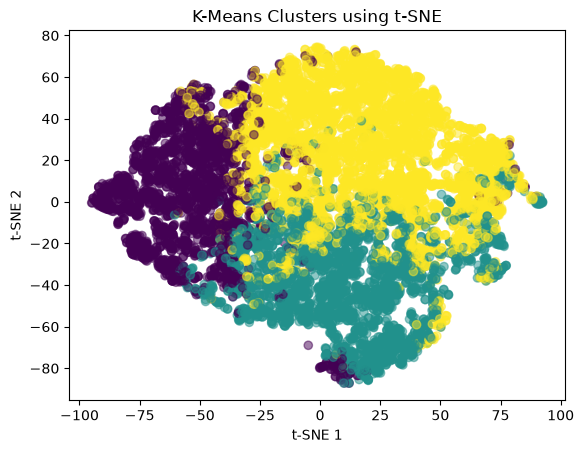

In [99]:
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df['KMeans'],
    alpha=0.5
)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('K-Means Clusters using t-SNE')
plt.show()